# Standalone FKPTJAX MG multipoles

This notebook uses only `fkptjax` APIs to:

1. build FKPT/FOLPS tables for an MG rescaling-branch example,
2. pass those tables through the FOLPS RSD path wrapped by `fkptjax.rsd`,
3. project to multipoles,
4. compare the explicit table route against `fkptjax.pipelines.rescale_branch_poles`,
5. compare an MG point against GR.

Important: this notebook assumes `src/fkptjax/pipelines.py` has the corrected split:

```python
table = tuple(table_w)
table_now_terms = tuple(table_now)
```

It intentionally does **not** define `make_table_state_fixed()` anymore, to avoid shadowing the package implementation.

In [1]:
# Environment and path setup
import os
import sys
from pathlib import Path

os.environ.setdefault("FOLPS_BACKEND", "jax")
os.environ.setdefault("JAX_PLATFORMS", "cpu")

# Make this notebook work from either repo root or examples/.
cwd = Path.cwd().resolve()
candidates = [cwd, cwd.parent]
for root in candidates:
    src = root / "src"
    if (src / "fkptjax").exists() and str(src) not in sys.path:
        sys.path.insert(0, str(src))
        print(f"Added to sys.path: {src}")
        break

print("cwd:", cwd)
print("python:", sys.executable)


Added to sys.path: /global/u2/c/crisjagq/FS_DR2/src/fkptjax_muMG/src
cwd: /global/u2/c/crisjagq/FS_DR2/src/fkptjax_muMG/examples
python: /global/common/software/desi/users/adematti/perlmutter/cosmodesiconda/20260321-1.0.0/conda/bin/python


In [2]:
# Imports and pipeline split sanity check
import time
import inspect
import importlib
import numpy as np

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp

from fkptjax.kfuncs_to_tables import build_jax_static_ctx, Kfuncs_to_tables_rescale_jax
import fkptjax.pipelines as pipelines
importlib.reload(pipelines)

from fkptjax.pipelines import make_table_state, rescale_branch_poles
from fkptjax.rsd import pack_fkpt_bias, tables_to_pkmu, project_to_poles

print("JAX version:", jax.__version__)
print("JAX devices:", jax.devices())
print("fkptjax.pipelines file:", pipelines.__file__)
print("\nCurrent split_folps_tables source:\n")
print(inspect.getsource(pipelines.split_folps_tables))

# Quick guard: the fixed split must preserve the full raw table, including k at index 0.
_tw = tuple(range(30))
_tn = tuple(range(32))
_table, _table_now, _, _ = pipelines.split_folps_tables(_tw, _tn)
assert len(_table) == 30 and len(_table_now) == 32, (
    "pipelines.py is still using the old truncated split. "
    "Update split_folps_tables so table=tuple(table_w) and table_now_terms=tuple(table_now)."
)
print("Pipeline split sanity check passed.")


JAX version: 0.9.1
JAX devices: [CpuDevice(id=0)]
fkptjax.pipelines file: /global/u2/c/crisjagq/FS_DR2/src/fkptjax_muMG/src/fkptjax/pipelines.py

Current split_folps_tables source:

def split_folps_tables(table_w: Sequence[Any], table_now: Sequence[Any]) -> tuple[tuple[Any, ...], tuple[Any, ...], tuple[Any, ...], tuple[Any, ...]]:
    """Split raw FKPT tables into FOLPS-ready wiggle/no-wiggle tables.

    The current A_full=False table layout is:

    - index ``0``: ``k`` grid;
    - indices ``1:``: FOLPS columns and scalar tails.

    FOLPS ``interp_table`` expects the full raw table, including ``k`` at
    ``table[0]``.  Do not drop the first element.
    """
    table = tuple(table_w)
    table_now_terms = tuple(table_now)
    scalars = tuple(table_w[28:])
    scalars_now = tuple(table_now[28:])
    return table, table_now_terms, scalars, scalars_now

Pipeline split sanity check passed.


In [12]:
# ISiTGR linear spectra and mu grid
# This replaces the toy P(k) by a real linear matter power spectrum from CAMB-ISiTGR.
#
# Important for the rescale-PS FKPT branch:
#   ISiTGR here should provide the GR/LCDM linear P(k).
#   FKPTJAX applies the MG rescaling internally through fkpt_kwargs, e.g. mu0=-0.5.
#   Do not use mu0 != 0 here unless you intentionally want MG twice.

import os
import numpy as np
import jax.numpy as jnp

import isitgr
from isitgr import model
from scipy.signal import savgol_filter

print("Using CAMB-ISiTGR", isitgr.__version__, "installed at", os.path.dirname(isitgr.__file__))


def make_mu_grid(nmu=8):
    x, w = np.polynomial.legendre.leggauss(nmu)
    return jnp.asarray(0.5 * (x + 1.0)), jnp.asarray(0.5 * w)


def smooth_now_savgol(k, pk, window=41, polyorder=3):
    """
    Simple standalone no-wiggle/smooth spectrum approximation.

    For a production comparison, replace this by your preferred Eisenstein-Hu
    or peak-average no-wiggle prescription. For this standalone FKPT example,
    this is good enough to avoid using the toy spectrum.
    """
    k = np.asarray(k, dtype=float)
    pk = np.asarray(pk, dtype=float)

    logpk = np.log(pk)

    # window must be odd and <= number of k points
    n = len(k)
    window = min(int(window), n - 1 if (n - 1) % 2 == 1 else n - 2)
    if window < polyorder + 2:
        window = polyorder + 3
    if window % 2 == 0:
        window += 1

    logpk_now = savgol_filter(logpk, window_length=window, polyorder=polyorder)
    return np.exp(logpk_now)


def get_isitgr_gr_linear_spectra(
    z=0.7,
    nk=256,
    minkh=1.0e-3,
    maxkh=1.0,
):
    pars = isitgr.CAMBparams()

    # GR/LCDM linear spectrum.
    # Using muSigma with mu0=0 is effectively GR in this setup.
    pars.set_cosmology(
        H0=67.36,
        ombh2=0.02237,
        omch2=0.12,
        mnu=0.06,
        omk=0.0,
        tau=0.0544,
        nnu=3.046,
        MG_parameterization="muSigma",
        mu0=0.0,
    )

    pars.InitPower.set_params(
        As=2.083e-9,
        ns=0.9649,
        r=0.0,
    )

    pars.set_accuracy(AccuracyBoost=2)
    pars.NonLinear = model.NonLinear_none
    pars.set_matter_power(redshifts=[z], kmax=maxkh)

    results = isitgr.get_results(pars)
    k, _, pk = results.get_matter_power_spectrum(
        minkh=minkh,
        maxkh=maxkh,
        npoints=nk,
    )

    pk = pk[0]
    pk_now = smooth_now_savgol(k, pk, window=41, polyorder=3)

    return jnp.asarray(k), jnp.asarray(pk), jnp.asarray(pk_now)


z_pk = 0.7

k_lin, pk_lin, pk_now_lin = get_isitgr_gr_linear_spectra(
    z=z_pk,
    nk=256,
    minkh=1.0e-3,
    maxkh=1.0,
)

k_eval = jnp.asarray(np.linspace(0.02, 0.20, 40))
mu, wmu = make_mu_grid(nmu=8)

# No AP distortion for this standalone example.
jac = jnp.asarray(1.0)
kap = k_eval[:, None] * jnp.ones_like(mu)[None, :]
muap = jnp.ones_like(k_eval)[:, None] * mu[None, :]

print("k_lin:", k_lin.shape, float(k_lin[0]), float(k_lin[-1]))
print("pk_lin:", pk_lin.shape, float(pk_lin[0]), float(pk_lin[-1]))
print("pk_now_lin:", pk_now_lin.shape, float(pk_now_lin[0]), float(pk_now_lin[-1]))
print("k_eval:", k_eval.shape, float(k_eval[0]), float(k_eval[-1]))
print("mu:", mu.shape)

Using CAMB-ISiTGR 1.6.5 installed at /global/homes/c/crisjagq/FS_DR2/src/isitgr_private/isitgr
k_lin: (256,) 0.001 0.9999999999999998
pk_lin: (256,) 1835.6214484678992 32.54790864165803
pk_now_lin: (256,) 1835.7606586325473 32.540503018236755
k_eval: (40,) 0.02 0.2
mu: (8,)


In [13]:
# Bias parameters packed in the FOLPS/FKPT order
bias = dict(
    b1=2.0,
    b2=0.0,
    bs2=0.0,
    b3nl=0.0,
    alpha0=0.0,
    alpha2=0.0,
    alpha4=0.0,
    ctilde=0.0,
    alpha0shot=0.0,
    alpha2shot=0.0,
)
nd = 1.0e-4
pars = pack_fkpt_bias(bias, nd=nd)
print("pars shape:", jnp.asarray(pars).shape)


pars shape: (12,)


In [14]:
# Build the static FKPT context once
t0 = time.time()
static_ctx = build_jax_static_ctx(
    k_lin,
    kmin=1.0e-3,
    kmax=1.0,
    Nk_kernel=120,
    nquadSteps=300,
    NQ=10,
    NR=10,
    rbao=104.0,
    pmax_bao=0.4,
    Np_bao=100,
)
print(f"static_ctx built in {time.time() - t0:.3f} s")


static_ctx built in 0.055 s


In [15]:
# FKPT MG settings for the rescaling branch
fkpt_kwargs = dict(
    z=0.7,
    Om=0.315,
    model="HDKI",
    mg_variant="mu_OmDE",
    mu0=-0.5,
    beyond_eds=False,
    rescale_PS=True,
    kmin=1.0e-3,
    kmax=1.0,
    Nk_kernel=120,
    nquadSteps=300,
    NQ=10,
    NR=10,
    xnow=-3.912023,
    f0_kmax=1.0e-3,
    static_ctx=static_ctx,
)


In [16]:
# Explicit low-level route:
# Kfuncs_to_tables_rescale_jax -> make_table_state -> tables_to_pkmu -> project_to_poles

t0 = time.time()
table_w, table_now, kernel_constants = Kfuncs_to_tables_rescale_jax(
    k=k_lin,
    pk=pk_lin,
    pk_now=pk_now_lin,
    return_kernel_constants=True,
    **fkpt_kwargs,
)

state = make_table_state(table_w, table_now, kernel_constants=kernel_constants)

print("raw table_w len:", len(table_w))
print("raw table_now len:", len(table_now))
print("FOLPS wiggle table len:", state.ncols)
print("FOLPS nowiggle table len:", len(state.table_now_terms))
assert state.ncols == len(table_w), "state.ncols should equal len(table_w); notebook is using a stale splitter."
assert len(state.table_now_terms) == len(table_now), "table_now_terms should equal len(table_now)."

pkmu = tables_to_pkmu(
    kap,
    muap,
    pars,
    state.table_all,
    ncols=state.ncols,
    bias_scheme="folps",
    IR_resummation=True,
    damping=None,
    A_full=False,
    use_TNS_model=False,
)

poles_explicit = project_to_poles(jac * pkmu, mu, wmu, ells=(0, 2, 4))
poles_explicit.block_until_ready()

print(f"explicit tables -> FOLPS -> poles time: {time.time() - t0:.3f} s")
print("pkmu shape:", pkmu.shape)
print("explicit poles shape:", poles_explicit.shape)
print("explicit finite:", bool(jnp.all(jnp.isfinite(poles_explicit))))
print("state kt shape:", jnp.asarray(state.kt).shape)


raw table_w len: 30
raw table_now len: 32
FOLPS wiggle table len: 30
FOLPS nowiggle table len: 32
explicit tables -> FOLPS -> poles time: 2.411 s
pkmu shape: (40, 8)
explicit poles shape: (3, 40)
explicit finite: True
state kt shape: (120,)


In [17]:
# High-level convenience route through fkptjax.pipelines
t0 = time.time()

poles_pipeline, state_pipeline = rescale_branch_poles(
    k=k_lin,
    pk=pk_lin,
    pk_now=pk_now_lin,
    jac=jac,
    kap=kap,
    muap=muap,
    pars=pars,
    mu=mu,
    wmu=wmu,
    ells=(0, 2, 4),
    bias_scheme="folps",
    IR_resummation=True,
    damping=None,
    A_full=False,
    use_TNS_model=False,
    return_kernel_constants=True,
    **fkpt_kwargs,
)

poles_pipeline.block_until_ready()

print(f"pipeline time: {time.time() - t0:.3f} s")
print("pipeline poles shape:", poles_pipeline.shape)
print("pipeline finite:", bool(jnp.all(jnp.isfinite(poles_pipeline))))
print("pipeline state ncols:", state_pipeline.ncols)
print("max |pipeline - explicit|:", float(jnp.max(jnp.abs(poles_pipeline - poles_explicit))))


pipeline time: 2.295 s
pipeline poles shape: (3, 40)
pipeline finite: True
pipeline state ncols: 30
max |pipeline - explicit|: 1.6825651982799172e-11


In [18]:
# Compare MG against GR in the same rescaling branch
gr_kwargs = dict(fkpt_kwargs)
gr_kwargs.update(model="GR", mg_variant="mu_OmDE", mu0=0.0)

poles_gr, state_gr = rescale_branch_poles(
    k=k_lin,
    pk=pk_lin,
    pk_now=pk_now_lin,
    jac=jac,
    kap=kap,
    muap=muap,
    pars=pars,
    mu=mu,
    wmu=wmu,
    ells=(0, 2, 4),
    bias_scheme="folps",
    IR_resummation=True,
    damping=None,
    A_full=False,
    use_TNS_model=False,
    return_kernel_constants=True,
    **gr_kwargs,
)
poles_gr.block_until_ready()

rel_mg = jnp.max(jnp.abs(poles_pipeline - poles_gr) / jnp.maximum(1.0, jnp.abs(poles_gr)))

print("GR poles shape:", poles_gr.shape)
print("GR finite:", bool(jnp.all(jnp.isfinite(poles_gr))))
print("GR state ncols:", state_gr.ncols)
print("max relative MG-vs-GR difference:", float(rel_mg))


GR poles shape: (3, 40)
GR finite: True
GR state ncols: 30
max relative MG-vs-GR difference: 0.20157872651247183


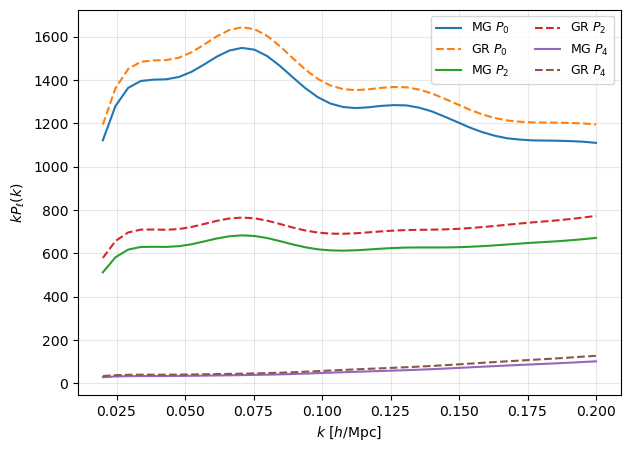

saved: /global/u2/c/crisjagq/FS_DR2/src/fkptjax_muMG/examples/standalone_mg_multipoles.npy
saved: /global/u2/c/crisjagq/FS_DR2/src/fkptjax_muMG/examples/standalone_mg_multipoles.png


In [19]:
# Quick plot and save outputs next to the notebook / current working directory
import matplotlib.pyplot as plt

outdir = Path.cwd()
np.save(outdir / "standalone_mg_multipoles.npy", np.asarray(poles_pipeline))

fig, ax = plt.subplots(figsize=(7, 5))
for iell, ell in enumerate((0, 2, 4)):
    ax.plot(np.asarray(k_eval), np.asarray(k_eval * poles_pipeline[iell]), label=fr"MG $P_{ell}$")
    ax.plot(np.asarray(k_eval), np.asarray(k_eval * poles_gr[iell]), ls="--", label=fr"GR $P_{ell}$")

ax.set_xlabel(r"$k\ [h/{\rm Mpc}]$")
ax.set_ylabel(r"$k P_\ell(k)$")
ax.legend(ncol=2, fontsize=9)
ax.grid(True, alpha=0.3)
#fig.savefig(outdir / "standalone_mg_multipoles.png", dpi=160, bbox_inches="tight")
plt.show()

print("saved:", outdir / "standalone_mg_multipoles.npy")
print("saved:", outdir / "standalone_mg_multipoles.png")
